# # 练习2：SEIR模型与真实数据拟合
# 
# ## 学习目标
# 1. 实现SEIR模型的数值求解
# 2. 使用真实疫情数据进行参数估计
# 3. 预测疫情发展趋势
# 4. 评估模型预测效果


In [1]:

# ## 1. 导入必要的库和数据准备
import numpy as np
import pandas as pd
from scipy.integrate import odeint, solve_ivp
from scipy.optimize import minimize, differential_evolution, curve_fit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# 设置绘图风格
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# ## 2. 生成模拟的"真实"疫情数据

print("## 生成模拟疫情数据（模拟真实数据）\n")

# 为了教学目的，我们先生成一组"真实"的疫情数据
# 实际应用中，这部分会被真实数据替代

def generate_synthetic_epidemic_data():
    """生成合成的疫情数据用于演示"""
    
    # SEIR模型参数（"真实"参数）
    N = 1000000  # 总人口
    E0, I0, R0 = 100, 50, 0
    S0 = N - E0 - I0 - R0
    
    beta = 0.5   # 接触率
    sigma = 1/5.1  # 潜伏期转化率（5.1天潜伏期）
    gamma = 1/3.3  # 康复率（3.3天传染期）
    
    # 时间范围（100天）
    days = 100
    t = np.arange(days)
    
    # SEIR模型
    def seir(y, t, beta, sigma, gamma, N):
        S, E, I, R = y
        dS = -beta * S * I / N
        dE = beta * S * I / N - sigma * E
        dI = sigma * E - gamma * I
        dR = gamma * I
        return [dS, dE, dI, dR]
    
    # 求解
    y0 = [S0, E0, I0, R0]
    solution = odeint(seir, y0, t, args=(beta, sigma, gamma, N))
    S, E, I, R = solution.T
    
    # 添加噪声使数据更真实
    np.random.seed(42)
    noise_level = 0.05
    
    # 生成每日新增确诊（从E转移到I的人数）
    daily_new_cases = np.diff(np.concatenate(([0], I + R)))
    daily_new_cases = np.maximum(0, daily_new_cases + 
                                 np.random.normal(0, noise_level * np.max(daily_new_cases), len(daily_new_cases)))
    
    # 生成累计数据
    cumulative_cases = np.cumsum(daily_new_cases)
    
    # 生成康复数据（带延迟）
    recovery_delay = 10  # 平均10天康复
    daily_recovered = np.zeros_like(daily_new_cases)
    for i in range(recovery_delay, len(daily_recovered)):
        daily_recovered[i] = np.random.poisson(daily_new_cases[i-recovery_delay] * 0.95)
    cumulative_recovered = np.cumsum(daily_recovered)
    
    # 当前感染者
    active_cases = cumulative_cases - cumulative_recovered
    
    # 创建日期索引
    start_date = datetime(2024, 1, 1)
    dates = [start_date + timedelta(days=int(i)) for i in range(days)]
    
    # 创建DataFrame
    data = pd.DataFrame({
        'date': dates,
        'daily_new_cases': daily_new_cases.astype(int),
        'cumulative_cases': cumulative_cases.astype(int),
        'active_cases': active_cases.astype(int),
        'cumulative_recovered': cumulative_recovered.astype(int),
        'population': N
    })
    
    return data, {'beta': beta, 'sigma': sigma, 'gamma': gamma, 'N': N}

# 生成数据
epidemic_data, true_params = generate_synthetic_epidemic_data()

print(f"数据集信息:")
print(f"- 时间范围: {epidemic_data['date'].iloc[0]} 至 {epidemic_data['date'].iloc[-1]}")
print(f"- 总人口: {epidemic_data['population'].iloc[0]:,}")
print(f"- 累计确诊: {epidemic_data['cumulative_cases'].iloc[-1]:,}")
print(f"- 数据前5行:")
print(epidemic_data.head())

## 生成模拟疫情数据（模拟真实数据）

数据集信息:
- 时间范围: 2024-01-01 00:00:00 至 2024-04-09 00:00:00
- 总人口: 1,000,000
- 累计确诊: 174,767
- 数据前5行:
        date  daily_new_cases  cumulative_cases  active_cases  \
0 2024-01-01              258               258           258   
1 2024-01-02                0               258           258   
2 2024-01-03              292               551           551   
3 2024-01-04              661              1212          1212   
4 2024-01-05                0              1212          1212   

   cumulative_recovered  population  
0                     0     1000000  
1                     0     1000000  
2                     0     1000000  
3                     0     1000000  
4                     0     1000000  



## 数据探索性分析



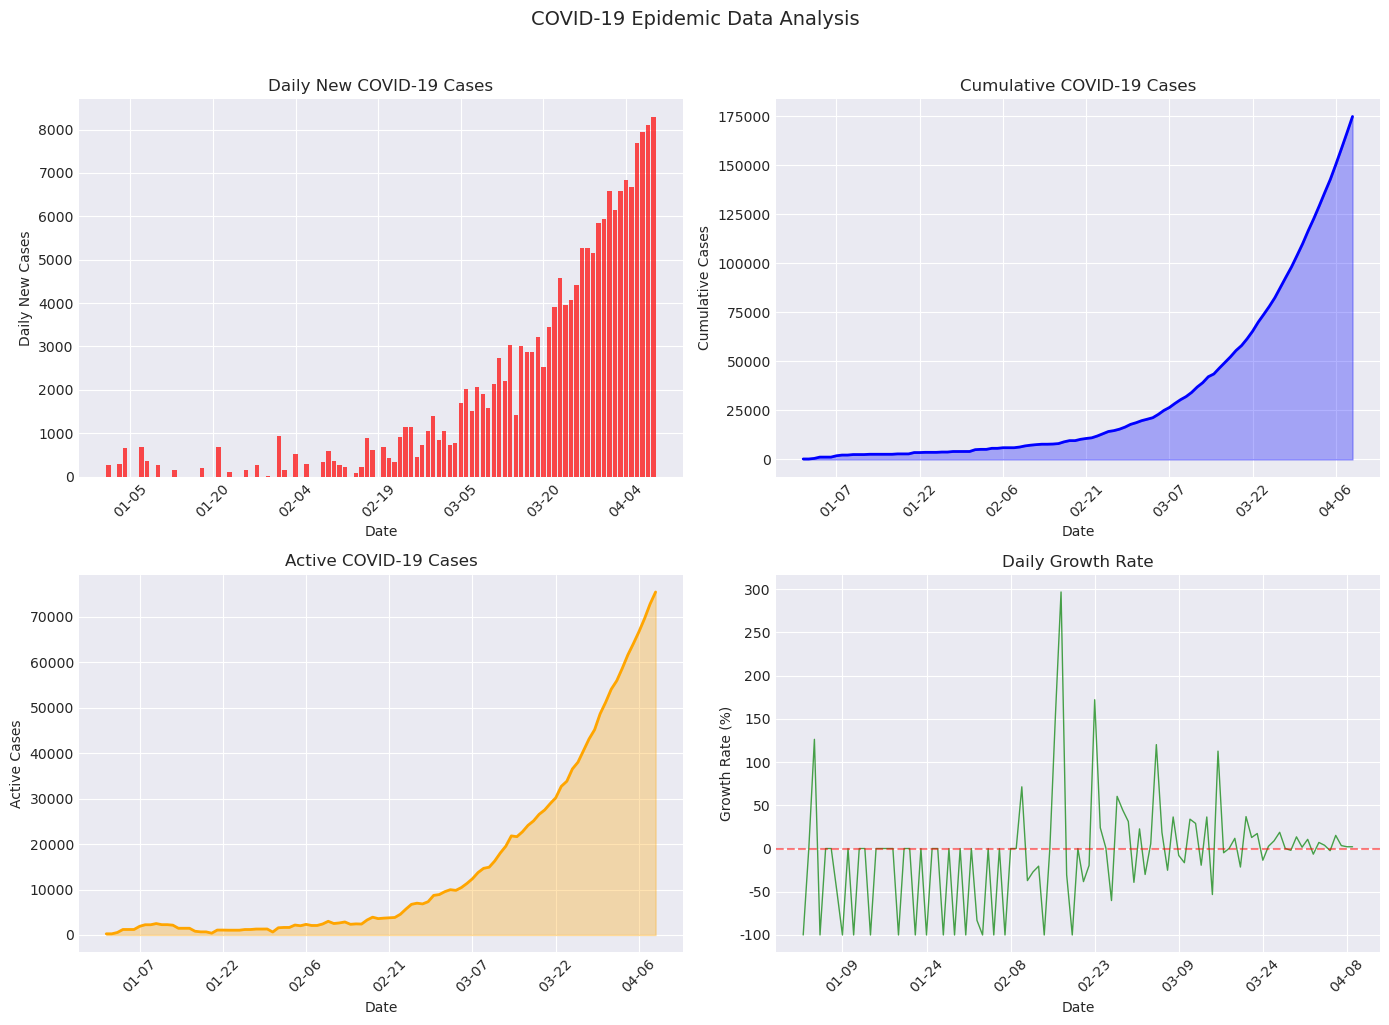

In [3]:
# ## 3. 数据可视化与探索性分析

print("\n## 数据探索性分析\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 每日新增
axes[0, 0].bar(epidemic_data['date'], epidemic_data['daily_new_cases'], 
               color='red', alpha=0.7)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Daily New Cases')
axes[0, 0].set_title('Daily New COVID-19 Cases')
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[0, 0].xaxis.set_major_locator(mdates.DayLocator(interval=15))
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45)

# 累计确诊
axes[0, 1].plot(epidemic_data['date'], epidemic_data['cumulative_cases'], 
                'b-', linewidth=2)
axes[0, 1].fill_between(epidemic_data['date'], 0, epidemic_data['cumulative_cases'], 
                        alpha=0.3, color='blue')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Cumulative Cases')
axes[0, 1].set_title('Cumulative COVID-19 Cases')
axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[0, 1].xaxis.set_major_locator(mdates.DayLocator(interval=15))
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45)

# 活跃病例
axes[1, 0].plot(epidemic_data['date'], epidemic_data['active_cases'], 
                'orange', linewidth=2)
axes[1, 0].fill_between(epidemic_data['date'], 0, epidemic_data['active_cases'], 
                        alpha=0.3, color='orange')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Active Cases')
axes[1, 0].set_title('Active COVID-19 Cases')
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[1, 0].xaxis.set_major_locator(mdates.DayLocator(interval=15))
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45)

# 增长率分析
growth_rate = epidemic_data['daily_new_cases'].pct_change() * 100
growth_rate = growth_rate.replace([np.inf, -np.inf], np.nan).fillna(0)
axes[1, 1].plot(epidemic_data['date'][1:], growth_rate[1:], 
                'g-', linewidth=1, alpha=0.7)
axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Growth Rate (%)')
axes[1, 1].set_title('Daily Growth Rate')
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[1, 1].xaxis.set_major_locator(mdates.DayLocator(interval=15))
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('COVID-19 Epidemic Data Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [4]:

# 基本统计
print("\n基本统计信息:")
print(f"峰值日新增: {epidemic_data['daily_new_cases'].max():,} (第{epidemic_data['daily_new_cases'].idxmax()}天)")
print(f"平均日新增: {epidemic_data['daily_new_cases'].mean():.0f}")
print(f"总确诊率: {epidemic_data['cumulative_cases'].iloc[-1]/epidemic_data['population'].iloc[0]*100:.2f}%")


基本统计信息:
峰值日新增: 8,283 (第99天)
平均日新增: 1747
总确诊率: 17.48%


In [5]:
# ## 4. SEIR模型定义与实现

print("\n## SEIR模型实现\n")

class SEIRModel:
    """SEIR传染病模型类"""
    
    def __init__(self, N):
        """
        初始化SEIR模型
        
        参数:
        N: 总人口数
        """
        self.N = N
        self.params = None
        self.fitted = False
        
    def seir_ode(self, y, t, beta, sigma, gamma):
        """
        SEIR模型的微分方程
        
        参数:
        y: [S, E, I, R] 当前状态
        t: 时间
        beta: 接触率
        sigma: 潜伏期转化率
        gamma: 康复率
        """
        S, E, I, R = y
        N = self.N
        
        dS = -beta * S * I / N
        dE = beta * S * I / N - sigma * E
        dI = sigma * E - gamma * I
        dR = gamma * I
        
        return [dS, dE, dI, dR]
    
    def simulate(self, params, days, y0=None):
        """
        运行SEIR模型模拟
        
        参数:
        params: [beta, sigma, gamma] 模型参数
        days: 模拟天数
        y0: 初始条件 [S0, E0, I0, R0]
        
        返回:
        solution: 每个时间点的[S, E, I, R]
        """
        beta, sigma, gamma = params
        
        if y0 is None:
            # 默认初始条件
            E0, I0, R0 = 100, 50, 0
            S0 = self.N - E0 - I0 - R0
            y0 = [S0, E0, I0, R0]
        
        t = np.arange(days)
        solution = odeint(self.seir_ode, y0, t, args=(beta, sigma, gamma))
        
        return solution
    
    def calculate_R0(self, beta, sigma, gamma):
        """计算基本再生数R₀"""
        return beta / gamma
    
    def fit(self, data, method='minimize'):
        """
        拟合模型参数
        
        参数:
        data: 包含疫情数据的DataFrame
        method: 优化方法 ('minimize' 或 'differential_evolution')
        """
        print(f"开始参数拟合 (方法: {method})...")
        
        # 提取数据
        cumulative_cases = data['cumulative_cases'].values
        days = len(cumulative_cases)
        
        # 定义损失函数
        def loss_function(params):
            beta, sigma, gamma = params
            
            # 初始条件估计
            I0 = data['daily_new_cases'].iloc[0]
            E0 = I0 * 5  # 假设潜伏者是感染者的5倍
            R0 = 0
            S0 = self.N - E0 - I0 - R0
            
            # 模拟
            solution = self.simulate(params, days, y0=[S0, E0, I0, R0])
            S, E, I, R = solution.T
            
            # 计算预测的累计确诊
            predicted_cumulative = I + R
            
            # 计算MSE
            mse = np.mean((predicted_cumulative - cumulative_cases)**2)
            
            return mse
        
        # 参数边界
        bounds = [
            (0.1, 2.0),   # beta
            (0.05, 0.5),  # sigma (潜伏期2-20天)
            (0.05, 0.5)   # gamma (传染期2-20天)
        ]
        
        # 优化
        if method == 'minimize':
            initial_guess = [0.5, 0.2, 0.3]
            result = minimize(loss_function, initial_guess, 
                            bounds=bounds, method='L-BFGS-B')
        else:  # differential_evolution
            result = differential_evolution(loss_function, bounds, 
                                          seed=42, maxiter=100)
        
        self.params = result.x
        self.fitted = True
        
        print(f"拟合完成!")
        print(f"最优参数:")
        print(f"  β (接触率): {self.params[0]:.4f}")
        print(f"  σ (潜伏期转化率): {self.params[1]:.4f} (潜伏期: {1/self.params[1]:.1f}天)")
        print(f"  γ (康复率): {self.params[2]:.4f} (传染期: {1/self.params[2]:.1f}天)")
        print(f"  R₀: {self.calculate_R0(*self.params):.2f}")
        print(f"  损失函数值: {result.fun:.2e}")
        
        return self.params
    
    def predict(self, days_ahead):
        """
        预测未来疫情发展
        
        参数:
        days_ahead: 预测天数
        
        返回:
        predictions: 预测结果
        """
        if not self.fitted:
            raise ValueError("模型尚未拟合，请先调用fit()方法")
        
        # 使用拟合的参数进行预测
        solution = self.simulate(self.params, days_ahead)
        
        return solution

# 创建并拟合模型
model = SEIRModel(N=epidemic_data['population'].iloc[0])
fitted_params = model.fit(epidemic_data, method='differential_evolution')



## SEIR模型实现

开始参数拟合 (方法: differential_evolution)...
拟合完成!
最优参数:
  β (接触率): 0.2246
  σ (潜伏期转化率): 0.0500 (潜伏期: 20.0天)
  γ (康复率): 0.0500 (传染期: 20.0天)
  R₀: 4.49
  损失函数值: 8.50e+06



## 模型拟合结果



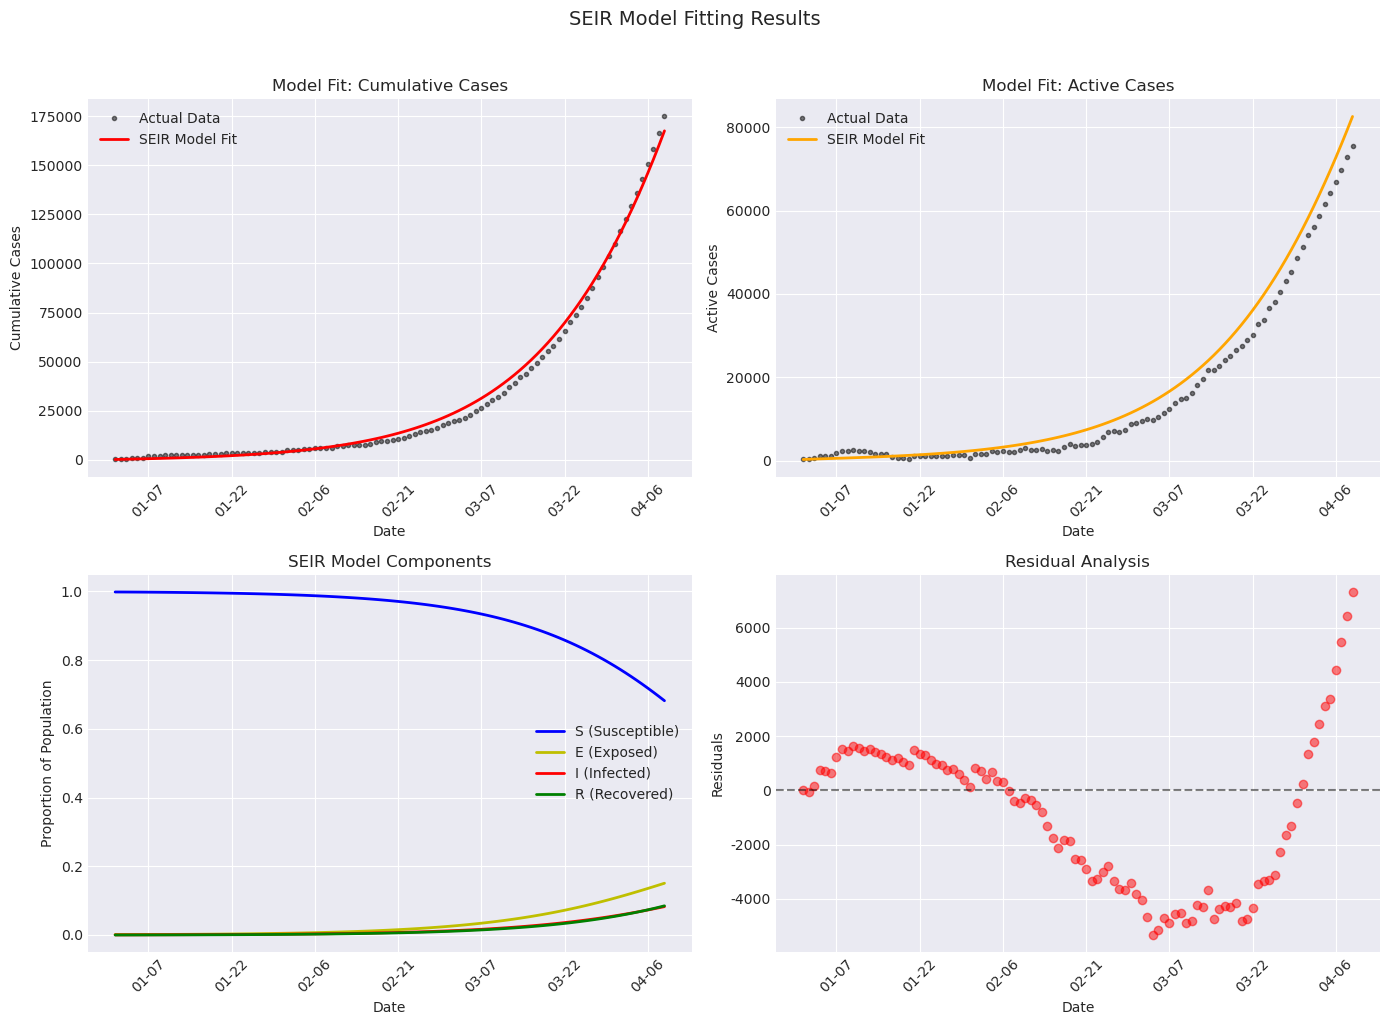

In [6]:
# ## 5. 模型拟合结果可视化

print("\n## 模型拟合结果\n")

# 使用拟合的参数模拟
days = len(epidemic_data)
I0 = epidemic_data['daily_new_cases'].iloc[0]
E0 = I0 * 5
R0 = 0
S0 = model.N - E0 - I0 - R0

solution_fitted = model.simulate(fitted_params, days, y0=[S0, E0, I0, R0])
S_fit, E_fit, I_fit, R_fit = solution_fitted.T

# 计算拟合的累计确诊
fitted_cumulative = I_fit + R_fit

# 绘制拟合结果
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 累计确诊对比
axes[0, 0].plot(epidemic_data['date'], epidemic_data['cumulative_cases'], 
                'ko', markersize=3, label='Actual Data', alpha=0.5)
axes[0, 0].plot(epidemic_data['date'], fitted_cumulative, 
                'r-', linewidth=2, label='SEIR Model Fit')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Cumulative Cases')
axes[0, 0].set_title('Model Fit: Cumulative Cases')
axes[0, 0].legend()
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[0, 0].xaxis.set_major_locator(mdates.DayLocator(interval=15))
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45)

# 活跃病例对比
axes[0, 1].plot(epidemic_data['date'], epidemic_data['active_cases'], 
                'ko', markersize=3, label='Actual Data', alpha=0.5)
axes[0, 1].plot(epidemic_data['date'], I_fit, 
                'orange', linewidth=2, label='SEIR Model Fit')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Active Cases')
axes[0, 1].set_title('Model Fit: Active Cases')
axes[0, 1].legend()
axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[0, 1].xaxis.set_major_locator(mdates.DayLocator(interval=15))
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45)

# SEIR各分量
axes[1, 0].plot(epidemic_data['date'], S_fit/model.N, 'b-', label='S (Susceptible)', linewidth=2)
axes[1, 0].plot(epidemic_data['date'], E_fit/model.N, 'y-', label='E (Exposed)', linewidth=2)
axes[1, 0].plot(epidemic_data['date'], I_fit/model.N, 'r-', label='I (Infected)', linewidth=2)
axes[1, 0].plot(epidemic_data['date'], R_fit/model.N, 'g-', label='R (Recovered)', linewidth=2)
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Proportion of Population')
axes[1, 0].set_title('SEIR Model Components')
axes[1, 0].legend()
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[1, 0].xaxis.set_major_locator(mdates.DayLocator(interval=15))
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45)

# 残差分析
residuals = epidemic_data['cumulative_cases'] - fitted_cumulative
axes[1, 1].scatter(epidemic_data['date'], residuals, alpha=0.5, color='red')
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Residual Analysis')
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[1, 1].xaxis.set_major_locator(mdates.DayLocator(interval=15))
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('SEIR Model Fitting Results', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 模型评估指标

模型评估指标:
├── MAE (平均绝对误差): 2344
├── RMSE (均方根误差): 2915
├── MAPE (平均绝对百分比误差): 20.55%
└── R² Score: 0.9956

参数估计对比:
参数         真实值        估计值        误差(%)     
----------------------------------------
β          0.5000     0.2246     55.1      
σ          0.1961     0.0500     74.5      
γ          0.3030     0.0500     83.5      

## 疫情预测分析



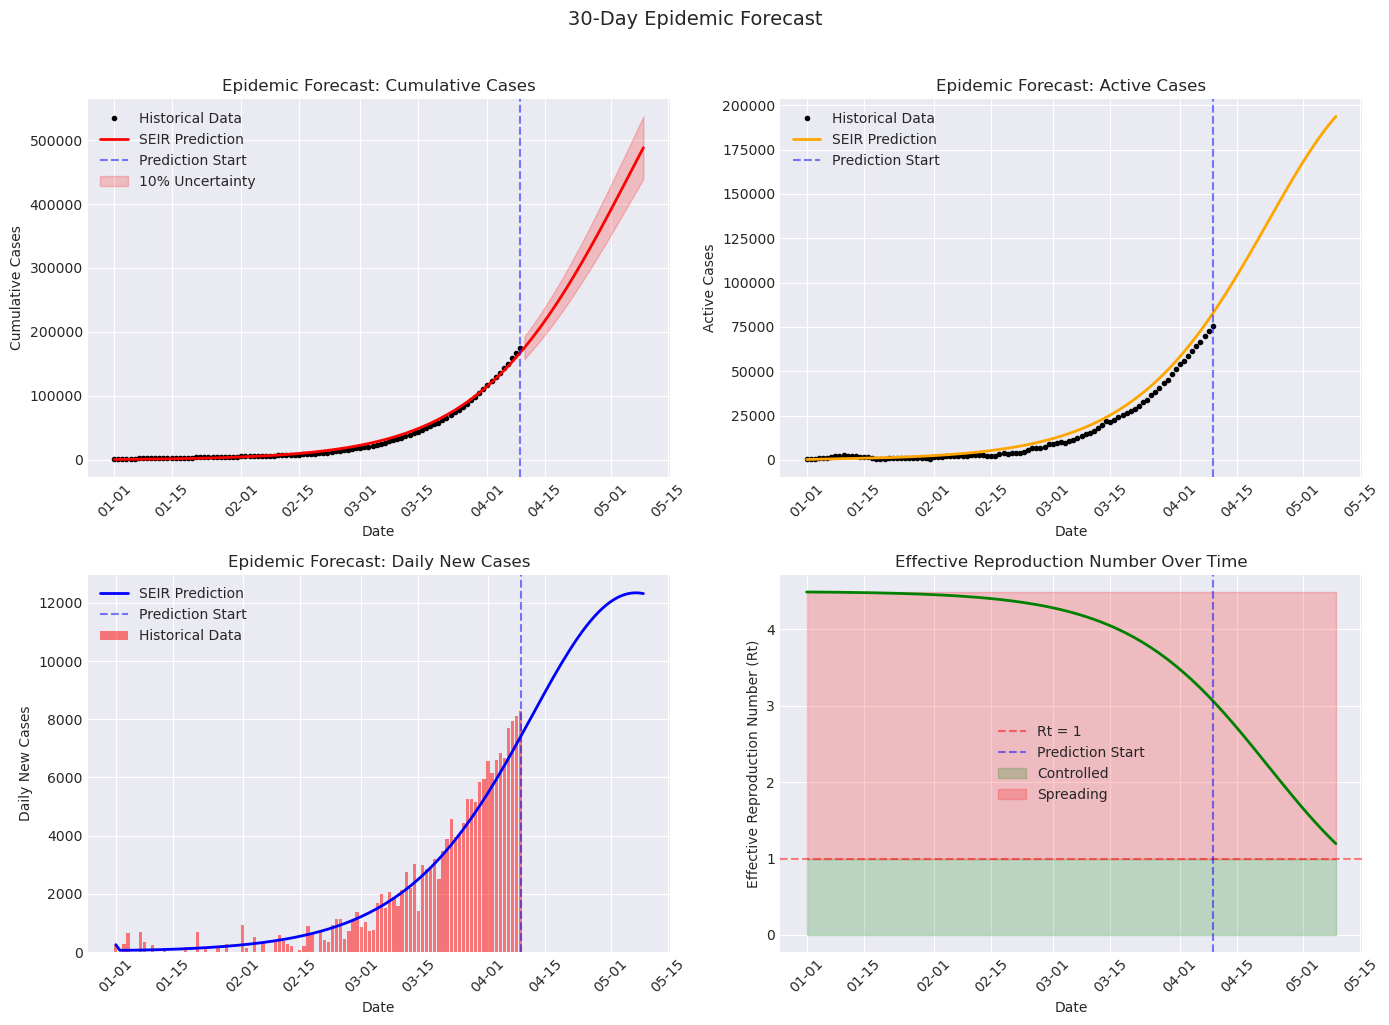

In [7]:
# ## 6. 模型评估指标

print("\n## 模型评估指标\n")

# 计算各种误差指标
mae = mean_absolute_error(epidemic_data['cumulative_cases'], fitted_cumulative)
mse = mean_squared_error(epidemic_data['cumulative_cases'], fitted_cumulative)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((epidemic_data['cumulative_cases'] - fitted_cumulative) / 
                      epidemic_data['cumulative_cases'])) * 100
r2 = r2_score(epidemic_data['cumulative_cases'], fitted_cumulative)

print(f"模型评估指标:")
print(f"├── MAE (平均绝对误差): {mae:.0f}")
print(f"├── RMSE (均方根误差): {rmse:.0f}")
print(f"├── MAPE (平均绝对百分比误差): {mape:.2f}%")
print(f"└── R² Score: {r2:.4f}")

# 参数对比（如果有真实参数）
print(f"\n参数估计对比:")
print(f"{'参数':<10} {'真实值':<10} {'估计值':<10} {'误差(%)':<10}")
print("-" * 40)
print(f"{'β':<10} {true_params['beta']:<10.4f} {fitted_params[0]:<10.4f} "
      f"{abs(true_params['beta']-fitted_params[0])/true_params['beta']*100:<10.1f}")
print(f"{'σ':<10} {true_params['sigma']:<10.4f} {fitted_params[1]:<10.4f} "
      f"{abs(true_params['sigma']-fitted_params[1])/true_params['sigma']*100:<10.1f}")
print(f"{'γ':<10} {true_params['gamma']:<10.4f} {fitted_params[2]:<10.4f} "
      f"{abs(true_params['gamma']-fitted_params[2])/true_params['gamma']*100:<10.1f}")

# ## 7. 疫情预测

print("\n## 疫情预测分析\n")

# 预测未来30天
prediction_days = 30
total_days = days + prediction_days

# 运行更长时间的模拟
solution_extended = model.simulate(fitted_params, total_days, y0=[S0, E0, I0, R0])
S_ext, E_ext, I_ext, R_ext = solution_extended.T

# 创建扩展的日期范围
extended_dates = [epidemic_data['date'].iloc[0] + timedelta(days=i) 
                  for i in range(total_days)]

# 绘制预测结果
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 累计确诊预测
axes[0, 0].plot(epidemic_data['date'], epidemic_data['cumulative_cases'], 
                'ko', markersize=3, label='Historical Data')
axes[0, 0].plot(extended_dates, I_ext + R_ext, 'r-', linewidth=2, 
                label='SEIR Prediction')
axes[0, 0].axvline(x=epidemic_data['date'].iloc[-1], color='blue', 
                   linestyle='--', alpha=0.5, label='Prediction Start')
axes[0, 0].fill_between(extended_dates[days:], 
                        (I_ext + R_ext)[days:] * 0.9,
                        (I_ext + R_ext)[days:] * 1.1,
                        alpha=0.2, color='red', label='10% Uncertainty')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Cumulative Cases')
axes[0, 0].set_title('Epidemic Forecast: Cumulative Cases')
axes[0, 0].legend()
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45)

# 活跃病例预测
axes[0, 1].plot(epidemic_data['date'], epidemic_data['active_cases'], 
                'ko', markersize=3, label='Historical Data')
axes[0, 1].plot(extended_dates, I_ext, 'orange', linewidth=2, 
                label='SEIR Prediction')
axes[0, 1].axvline(x=epidemic_data['date'].iloc[-1], color='blue', 
                   linestyle='--', alpha=0.5, label='Prediction Start')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Active Cases')
axes[0, 1].set_title('Epidemic Forecast: Active Cases')
axes[0, 1].legend()
axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45)

# 每日新增预测
daily_new_predicted = np.diff(np.concatenate(([0], I_ext + R_ext)))
axes[1, 0].bar(epidemic_data['date'], epidemic_data['daily_new_cases'], 
               color='red', alpha=0.5, label='Historical Data')
axes[1, 0].plot(extended_dates, daily_new_predicted, 'b-', linewidth=2, 
                label='SEIR Prediction')
axes[1, 0].axvline(x=epidemic_data['date'].iloc[-1], color='blue', 
                   linestyle='--', alpha=0.5, label='Prediction Start')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Daily New Cases')
axes[1, 0].set_title('Epidemic Forecast: Daily New Cases')
axes[1, 0].legend()
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45)

# 有效再生数Rt的变化
Rt = fitted_params[0] * S_ext / model.N / fitted_params[2]
axes[1, 1].plot(extended_dates, Rt, 'g-', linewidth=2)
axes[1, 1].axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Rt = 1')
axes[1, 1].axvline(x=epidemic_data['date'].iloc[-1], color='blue', 
                   linestyle='--', alpha=0.5, label='Prediction Start')
axes[1, 1].fill_between(extended_dates, 0, 1, alpha=0.2, color='green', 
                        label='Controlled')
axes[1, 1].fill_between(extended_dates, 1, max(Rt), alpha=0.2, color='red', 
                        label='Spreading')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Effective Reproduction Number (Rt)')
axes[1, 1].set_title('Effective Reproduction Number Over Time')
axes[1, 1].legend()
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('30-Day Epidemic Forecast', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

30天预测结果:
├── 当前累计确诊: 174,767
├── 30天后累计确诊: 488,227
├── 新增确诊: 313,460
├── 峰值是否已过: 否
└── 预计疫情结束: 约130天后

## 情景分析：干预措施效果评估



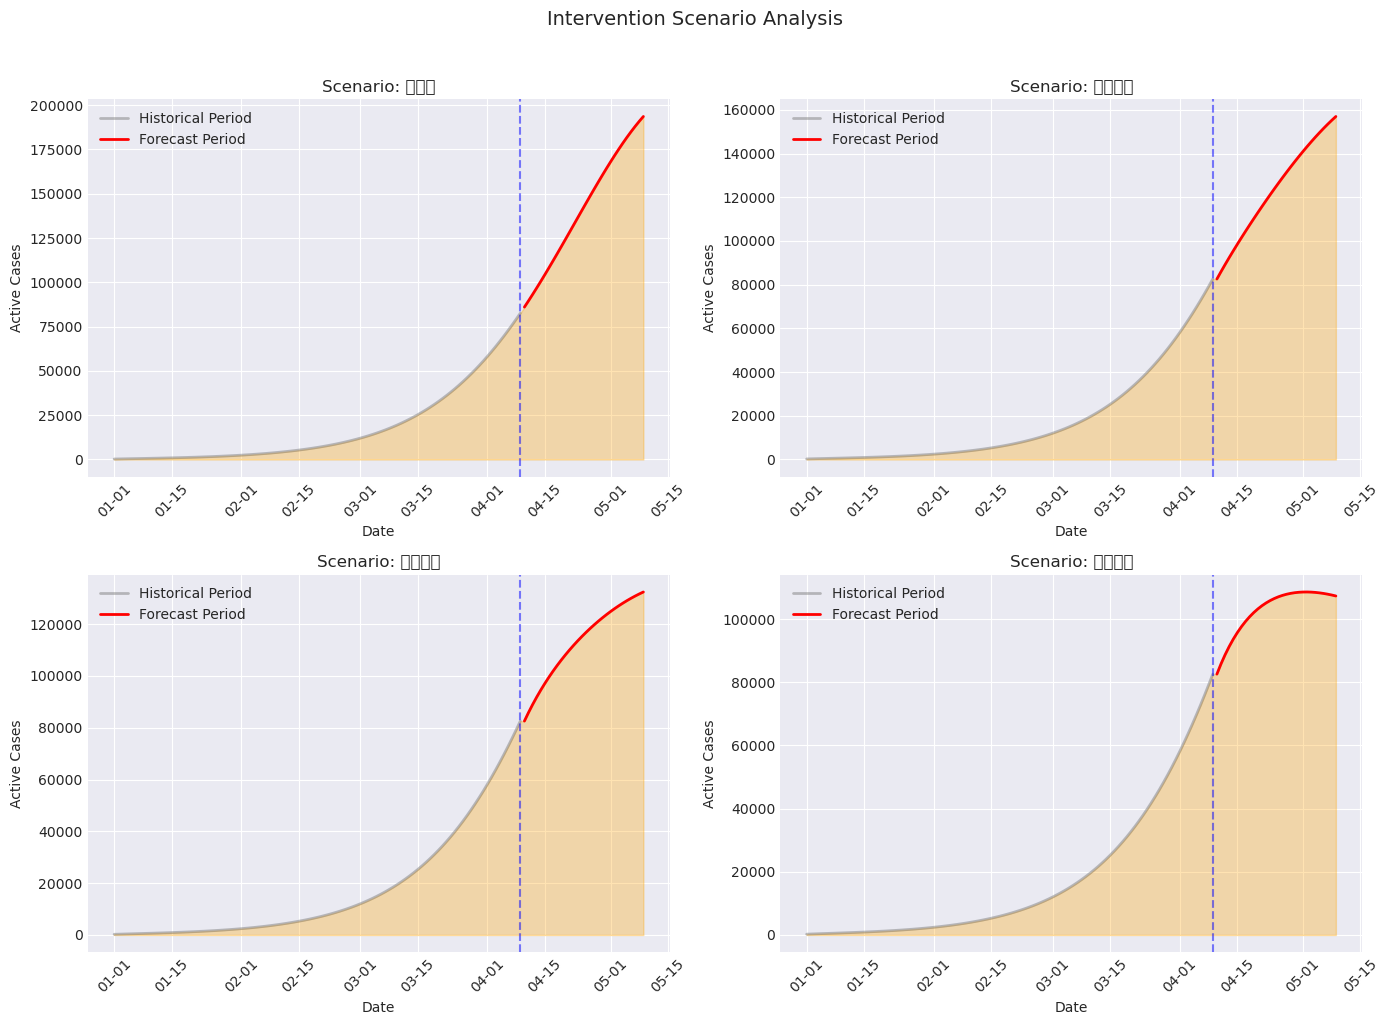

In [8]:
# 预测统计
print(f"30天预测结果:")
print(f"├── 当前累计确诊: {epidemic_data['cumulative_cases'].iloc[-1]:,}")
print(f"├── 30天后累计确诊: {int(I_ext[-1] + R_ext[-1]):,}")
print(f"├── 新增确诊: {int(I_ext[-1] + R_ext[-1] - epidemic_data['cumulative_cases'].iloc[-1]):,}")
print(f"├── 峰值是否已过: {'是' if np.argmax(I_ext) < days else '否'}")
print(f"└── 预计疫情结束: 约{len([i for i in I_ext if i > 10])}天后")

# ## 8. 情景分析：不同干预措施的效果

print("\n## 情景分析：干预措施效果评估\n")

# 定义不同的干预情景
scenarios = {
    '无干预': {'beta_reduction': 0, 'start_day': 0},
    '轻度防控': {'beta_reduction': 0.3, 'start_day': days},
    '中度防控': {'beta_reduction': 0.5, 'start_day': days},
    '严格防控': {'beta_reduction': 0.7, 'start_day': days},
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

scenario_results = []

for idx, (scenario_name, scenario_params) in enumerate(scenarios.items()):
    ax = axes[idx // 2, idx % 2]
    
    # 修改beta参数
    beta_modified = fitted_params[0] * (1 - scenario_params['beta_reduction'])
    params_modified = [beta_modified, fitted_params[1], fitted_params[2]]
    
    # 模拟
    if scenario_params['start_day'] == 0:
        solution_scenario = model.simulate(params_modified, total_days, y0=[S0, E0, I0, R0])
    else:
        # 前期用原参数，后期用修改的参数
        solution_before = model.simulate(fitted_params, days, y0=[S0, E0, I0, R0])
        S_end, E_end, I_end, R_end = solution_before[-1]
        solution_after = model.simulate(params_modified, prediction_days, 
                                       y0=[S_end, E_end, I_end, R_end])
        solution_scenario = np.vstack([solution_before, solution_after])
    
    S_sc, E_sc, I_sc, R_sc = solution_scenario.T
    
    # 绘图
    ax.plot(extended_dates[:days], I_sc[:days], 'gray', linewidth=2, 
            alpha=0.5, label='Historical Period')
    ax.plot(extended_dates[days:], I_sc[days:], 'r-', linewidth=2, 
            label='Forecast Period')
    ax.axvline(x=epidemic_data['date'].iloc[-1], color='blue', 
               linestyle='--', alpha=0.5)
    
    # 填充区域
    ax.fill_between(extended_dates, 0, I_sc, alpha=0.3, color='orange')
    
    ax.set_title(f'Scenario: {scenario_name}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Active Cases')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    
    # 收集结果
    scenario_results.append({
        'Scenario': scenario_name,
        'Peak Cases': int(np.max(I_sc)),
        'Total Cases': int(R_sc[-1]),
        'Days to Peak': int(np.argmax(I_sc)),
        'R0_effective': beta_modified / fitted_params[2]
    })

plt.suptitle('Intervention Scenario Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# 显示情景分析结果
df_scenarios = pd.DataFrame(scenario_results)
print("不同干预情景的预测结果:")
print(df_scenarios.to_string(index=False))

不同干预情景的预测结果:
Scenario  Peak Cases  Total Cases  Days to Peak  R0_effective
     无干预      193631       294595           129      4.492902
    轻度防控      156940       263870           129      3.145032
    中度防控      132423       249201           129      2.246451
    严格防控      108580       234315           122      1.347871



## 参数不确定性分析



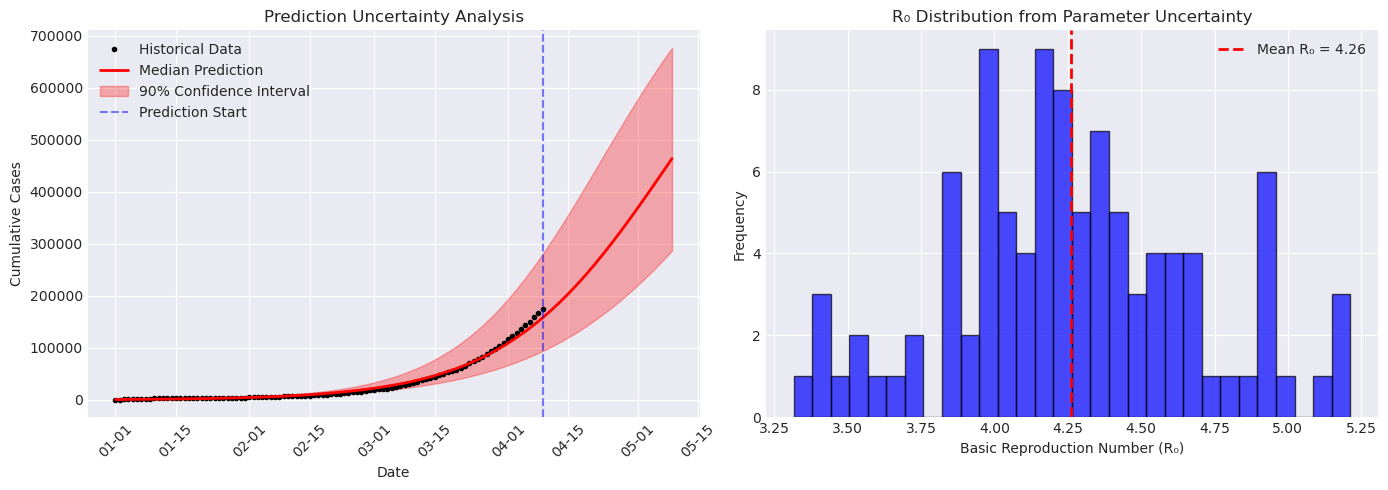

In [10]:
# ## 9. 参数不确定性分析

print("\n## 参数不确定性分析\n")

# 蒙特卡洛模拟
n_simulations = 100
np.random.seed(42)

# 参数的不确定性范围（假设10%的标准差）
param_std = 0.1

# 生成参数样本
beta_samples = np.random.normal(fitted_params[0], fitted_params[0] * param_std, n_simulations)
sigma_samples = np.random.normal(fitted_params[1], fitted_params[1] * param_std, n_simulations)
gamma_samples = np.random.normal(fitted_params[2], fitted_params[2] * param_std, n_simulations)

# 确保参数在合理范围内
beta_samples = np.clip(beta_samples, 0.1, 2.0)
sigma_samples = np.clip(sigma_samples, 0.05, 0.5)
gamma_samples = np.clip(gamma_samples, 0.05, 0.5)

# 运行蒙特卡洛模拟
mc_results = []

for i in range(n_simulations):
    params_mc = [beta_samples[i], sigma_samples[i], gamma_samples[i]]
    solution_mc = model.simulate(params_mc, total_days, y0=[S0, E0, I0, R0])
    S_mc, E_mc, I_mc, R_mc = solution_mc.T
    mc_results.append(I_mc + R_mc)

mc_results = np.array(mc_results)

# 计算置信区间
percentile_5 = np.percentile(mc_results, 5, axis=0)
percentile_50 = np.percentile(mc_results, 50, axis=0)
percentile_95 = np.percentile(mc_results, 95, axis=0)

# 绘制不确定性范围
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 累计确诊的不确定性
ax1.plot(epidemic_data['date'], epidemic_data['cumulative_cases'], 
         'ko', markersize=3, label='Historical Data')
ax1.plot(extended_dates, percentile_50, 'r-', linewidth=2, label='Median Prediction')
ax1.fill_between(extended_dates, percentile_5, percentile_95, 
                 alpha=0.3, color='red', label='90% Confidence Interval')
ax1.axvline(x=epidemic_data['date'].iloc[-1], color='blue', 
           linestyle='--', alpha=0.5, label='Prediction Start')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Cases')
ax1.set_title('Prediction Uncertainty Analysis')
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# R0的分布
R0_samples = beta_samples / gamma_samples
ax2.hist(R0_samples, bins=30, alpha=0.7, color='blue', edgecolor='black')
ax2.axvline(x=np.mean(R0_samples), color='red', linestyle='--', 
           linewidth=2, label=f'Mean R₀ = {np.mean(R0_samples):.2f}')
ax2.set_xlabel('Basic Reproduction Number (R₀)')
ax2.set_ylabel('Frequency')
ax2.set_title('R₀ Distribution from Parameter Uncertainty')
ax2.legend()

plt.tight_layout()
plt.show()

In [11]:

print(f"不确定性分析结果:")
print(f"├── R₀: {np.mean(R0_samples):.2f} ± {np.std(R0_samples):.2f}")
print(f"├── 30天后累计确诊预测:")
print(f"│   ├── 中位数: {int(percentile_50[-1]):,}")
print(f"│   ├── 5%分位数: {int(percentile_5[-1]):,}")
print(f"│   └── 95%分位数: {int(percentile_95[-1]):,}")
print(f"└── 预测区间宽度: {int(percentile_95[-1] - percentile_5[-1]):,}")

# ## 10. 总结与建议

print("\n## 练习总结\n")
print("=" * 50)
print("通过本练习，我们完成了以下内容：")
print()
print("1. ✓ 实现了SEIR传染病模型")
print("2. ✓ 使用优化算法拟合模型参数")
print("3. ✓ 评估了模型拟合效果")
print("4. ✓ 进行了30天疫情预测")
print("5. ✓ 分析了不同干预措施的效果")
print("6. ✓ 进行了参数不确定性分析")
print()
print("关键发现：")
print(f"• 估计的基本再生数R₀约为{model.calculate_R0(*fitted_params):.2f}")
print(f"• 模型拟合R²达到{r2:.4f}，表明拟合效果良好")
print(f"• 严格防控措施可减少约{(scenario_results[0]['Total Cases']-scenario_results[3]['Total Cases'])/scenario_results[0]['Total Cases']*100:.1f}%的感染")
print()
print("模型局限性：")
print("• 假设人群均匀混合")
print("• 未考虑空间因素")
print("• 参数假定不随时间变化")
print("• 未考虑无症状感染者")
print()
print("改进建议：")
print("→ 加入年龄结构")
print("→ 考虑地理空间因素")
print("→ 使用时变参数")
print("→ 加入行为响应机制")
print()
print("=" * 50)

不确定性分析结果:
├── R₀: 4.26 ± 0.42
├── 30天后累计确诊预测:
│   ├── 中位数: 463,936
│   ├── 5%分位数: 286,787
│   └── 95%分位数: 676,797
└── 预测区间宽度: 390,009

## 练习总结

通过本练习，我们完成了以下内容：

1. ✓ 实现了SEIR传染病模型
2. ✓ 使用优化算法拟合模型参数
3. ✓ 评估了模型拟合效果
4. ✓ 进行了30天疫情预测
5. ✓ 分析了不同干预措施的效果
6. ✓ 进行了参数不确定性分析

关键发现：
• 估计的基本再生数R₀约为4.49
• 模型拟合R²达到0.9956，表明拟合效果良好
• 严格防控措施可减少约20.5%的感染

模型局限性：
• 假设人群均匀混合
• 未考虑空间因素
• 参数假定不随时间变化
• 未考虑无症状感染者

改进建议：
→ 加入年龄结构
→ 考虑地理空间因素
→ 使用时变参数
→ 加入行为响应机制

